<a href="https://colab.research.google.com/github/sadaffatimaee/DATA266_Lab1_Team16/blob/main/%20%20%20task1_llm/Sadaf_Fatima_Syeda/src/task1_sadaf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:

SMOKE = False

CFG = dict(
    member        = "Sadaf_Fatima_Syeda",
    seed          = 266,
    # data
    n_train_chars = 100_000,
    n_val_chars   = 10_000,
    stride        = 4,
    # model
    n_layer       = 6,
    n_embd        = 192,
    n_head        = 6,
    block_size    = 256,
    dropout       = 0.2,
    activation    = "ReLU",
    # optimizer
    batch_size    = 32,
    epochs        = 10,
    lr            = 6e-4,
    min_lr_frac   = 0.1,
    warmup_frac   = 0.05,
    weight_decay  = 0.1,
    grad_clip     = 1.0,
    amp           = True,
    # generation
    gen_tokens    = 500,
    temperature   = 0.8,
)
if SMOKE:
    CFG.update(n_layer=2, n_embd=48, n_head=2, block_size=32, epochs=1, stride=64,
               batch_size=16, gen_tokens=100, amp=False)
print(CFG)

{'member': 'Sadaf_Fatima_Syeda', 'seed': 266, 'n_train_chars': 100000, 'n_val_chars': 10000, 'stride': 4, 'n_layer': 6, 'n_embd': 192, 'n_head': 6, 'block_size': 256, 'dropout': 0.2, 'activation': 'ReLU', 'batch_size': 32, 'epochs': 10, 'lr': 0.0006, 'min_lr_frac': 0.1, 'warmup_frac': 0.05, 'weight_decay': 0.1, 'grad_clip': 1.0, 'amp': True, 'gen_tokens': 500, 'temperature': 0.8}


In [11]:

import os, sys, json, time, math, random, platform, subprocess, datetime
import torch

OUT   = f"task1_llm/{CFG['member']}"
DIRS  = {k: f"{OUT}/{k}" for k in ["src", "checkpoints", "outputs", "data_processed"]}
LOGD, MAND = "reproducibility/raw_logs", "reproducibility/manifests"
for d in list(DIRS.values()) + [LOGD, MAND]:
    os.makedirs(d, exist_ok=True)

random.seed(CFG["seed"]); torch.manual_seed(CFG["seed"])
device = 'cuda' if torch.cuda.is_available() else 'cpu'

RUN_ID   = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
LOG_PATH = f"{LOGD}/task1_sadaf_{RUN_ID}.log"
_logf = open(LOG_PATH, "a", buffering=1)
def log(msg=""):
    line = f"[{datetime.datetime.now().isoformat(timespec='seconds')}] {msg}"
    print(line); _logf.write(line + "\n")

def sh(cmd):
    try: return subprocess.run(cmd, shell=True, capture_output=True, text=True).stdout.strip()
    except Exception as e: return f"n/a ({e})"

log(f"RUN_ID {RUN_ID}")
log(f"python {sys.version.split()[0]} | torch {torch.__version__} | device {device}")
log(f"GPU: {torch.cuda.get_device_name(0) if device == 'cuda' else 'none'}")
log("nvidia-smi:\n" + (sh("nvidia-smi") or "n/a"))
log(f"CPU: {platform.processor() or platform.machine()} | {os.cpu_count()} cores")
log("lscpu model: " + sh("lscpu | grep 'Model name'"))
log("CONFIG " + json.dumps(CFG))
json.dump(CFG, open(f"{DIRS['outputs']}/config.json", "w"), indent=2)

[2026-09-26T05:06:56] RUN_ID 20260926_050656
[2026-09-26T05:06:56] python 3.13.15 | torch 2.11.0+cu128 | device cuda
[2026-09-26T05:06:56] GPU: Tesla T4
[2026-09-26T05:06:56] nvidia-smi:
Sat Sep 26 05:06:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   70C    P0             32W /   70W |  

In [12]:

# 2. Download TinyStories
import os, urllib.request, shutil

shutil.rmtree('tinystories_data', ignore_errors=True)
if os.path.exists('tinystories.zip'): os.remove('tinystories.zip')
os.makedirs('tinystories_data', exist_ok=True)

file_path = 'tinystories_data/TinyStoriesV2-GPT4-valid.txt'
urllib.request.urlretrieve(
    "https://huggingface.co/datasets/roneneldan/TinyStories/resolve/main/TinyStoriesV2-GPT4-valid.txt",
    file_path)

print("Using:", file_path, f"({os.path.getsize(file_path)/1e6:.1f} MB)")
log(f'dataset file: {file_path} ({os.path.getsize(file_path)/1e6:.1f} MB)')

Using: tinystories_data/TinyStoriesV2-GPT4-valid.txt (22.5 MB)
[2026-09-26T05:07:00] dataset file: tinystories_data/TinyStoriesV2-GPT4-valid.txt (22.5 MB)


In [13]:
# 3. Character level tokenizer and 100K / 10K split
with open(file_path, 'r', encoding='utf-8') as f:
    text = f.read()

chars = sorted(list(set(text)))
vocab_size = len(chars)
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [char_to_idx[c] for c in s]
decode = lambda ids: "".join(idx_to_char[i] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)
n_tr, n_va = CFG["n_train_chars"], CFG["n_val_chars"]
train_data = data[:n_tr].clone()
val_data   = data[n_tr:n_tr + n_va].clone()

T = CFG["block_size"]
def make_windows(d, stride):
    starts = torch.arange(0, len(d) - T - 1, stride)
    X = torch.stack([d[s:s+T] for s in starts])
    Y = torch.stack([d[s+1:s+T+1] for s in starts])
    return X, Y

X_train, Y_train = make_windows(train_data, CFG["stride"])
X_val,   Y_val   = make_windows(val_data, T)          # no overlap for validation

# Save the split and vocab
torch.save({"train_data": train_data, "val_data": val_data,
            "block_size": T, "stride": CFG["stride"], "n_train_windows": len(X_train), "n_val_windows": len(X_val),
            "chars": chars, "char_to_idx": char_to_idx, "idx_to_char": idx_to_char,
            "source_file": os.path.basename(file_path), "cfg": CFG},
           f"{DIRS['data_processed']}/split.pt")

log(f"source {os.path.basename(file_path)} | total chars {len(data):,} | vocab {vocab_size}")
log(f"train chars {len(train_data):,} -> {len(X_train):,} sequences of {T} | "
    f"val chars {len(val_data):,} -> {len(X_val):,} sequences")
log("sample text: " + repr(text[:200]))

[2026-09-26T05:07:07] source TinyStoriesV2-GPT4-valid.txt | total chars 22,493,387 | vocab 91
[2026-09-26T05:07:07] train chars 100,000 -> 24,936 sequences of 256 | val chars 10,000 -> 39 sequences
[2026-09-26T05:07:07] sample text: 'u don\'t have to be scared of the loud dog, I\'ll protect you". The mole felt so safe with the little girl. She was very kind and the mole soon came to trust her. He leaned against her and she kept him '


In [14]:
# 4. Model components (from-scratch attention, LayerNorm, FFN, residuals) — hyperparameters from CFG
import torch.nn as nn
from torch.nn import functional as F

n_embd, n_head, n_layer = CFG["n_embd"], CFG["n_head"], CFG["n_layer"]
block_size, dropout     = CFG["block_size"], CFG["dropout"]
batch_size              = CFG["batch_size"]

class Head(nn.Module):
    """ One head of self-attention built from scratch """
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)   # (B, T, head_size)
        q = self.query(x) # (B, T, head_size)

        # Compute attention scores ("affinities")
        wei = q @ k.transpose(-2, -1) * (C ** -0.5) # (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # Mask future tokens
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)

        # Perform the weighted aggregation of the values
        v = self.value(x) # (B, T, head_size)
        out = wei @ v     # (B, T, head_size)
        return out

class MultiHeadAttention(nn.Module):
    """ Multiple heads of self-attention in parallel """
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedForward(nn.Module):
    """ A simple linear layer followed by a non-linearity """
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

print("Attention heads and Transformer blocks defined successfully!")

Attention heads and Transformer blocks defined successfully!


In [15]:
# 5. GPT model
class GPTLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device))
        x = self.ln_f(self.blocks(tok_emb + pos_emb))
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B*T, C).float(), targets.view(B*T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, greedy=False):
        for _ in range(max_new_tokens):
            logits, _ = self(idx[:, -block_size:])
            logits = logits[:, -1, :].float()
            if greedy:
                nxt = logits.argmax(-1, keepdim=True)
            else:
                probs = F.softmax(logits / temperature, dim=-1)
                nxt = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, nxt), dim=1)
        return idx

In [16]:
# 6. Train: AdamW + linear warm-up → linear decay, epochs over fixed-length sequences,
#    per-epoch checkpoints, grad-norm / spike / NaN tracking, everything logged
model = GPTLanguageModel().to(device)
param_count = sum(p.numel() for p in model.parameters())
log(f"Parameters: {param_count:,}")

steps_per_epoch = math.ceil(len(X_train) / batch_size)
total_steps  = steps_per_epoch * CFG["epochs"]
warmup_steps = max(1, int(CFG["warmup_frac"] * total_steps))
log(f"steps/epoch {steps_per_epoch} | total steps {total_steps} | warmup {warmup_steps}")

optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
def lr_lambda(step):
    if step < warmup_steps:
        return (step + 1) / warmup_steps
    prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 1.0 - (1.0 - CFG["min_lr_frac"]) * prog
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

use_amp = CFG["amp"] and device == 'cuda'
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
autocast = lambda: torch.autocast(device_type='cuda', dtype=torch.float16, enabled=use_amp)

@torch.no_grad()
def evaluate(X, Y, bs=64):
    model.eval()
    tot_loss, tot_correct, tot_n = 0.0, 0, 0
    for i in range(0, len(X), bs):
        xb, yb = X[i:i+bs].to(device), Y[i:i+bs].to(device)
        with autocast():
            logits, loss = model(xb, yb)
        tot_loss += loss.item() * yb.numel()
        tot_correct += (logits.argmax(-1) == yb).sum().item()
        tot_n += yb.numel()
    model.train()
    return tot_loss / tot_n, tot_correct / tot_n

g = torch.Generator().manual_seed(CFG["seed"])
_tr_idx = torch.randperm(len(X_train), generator=g)[:max(len(X_val) * 4, 64)]   # fixed train subset for train-loss eval
X_tr_eval, Y_tr_eval = X_train[_tr_idx], Y_train[_tr_idx]

history = dict(epoch=[], train_loss=[], val_loss=[], val_acc=[], lr=[])
step_losses, grad_norms, lrs = [], [], []
nan_losses, loss_spikes, ema = 0, 0, None
best_val = float("inf")
if device == 'cuda':
    torch.cuda.reset_peak_memory_stats()

model.train()
start_time = time.time()
step = 0
for epoch in range(1, CFG["epochs"] + 1):
    perm = torch.randperm(len(X_train), generator=g)
    run_loss = 0.0
    for b in range(steps_per_epoch):
        ix = perm[b*batch_size:(b+1)*batch_size]
        xb, yb = X_train[ix].to(device, non_blocking=True), Y_train[ix].to(device, non_blocking=True)
        with autocast():
            _, loss = model(xb, yb)
        lv = loss.item()
        if math.isnan(lv) or math.isinf(lv):
            nan_losses += 1
            log(f"step {step}: NaN/inf loss — skipping update")
            optimizer.zero_grad(set_to_none=True); scheduler.step(); step += 1
            continue
        if ema is not None and lv > 1.5 * ema:
            loss_spikes += 1
            log(f"step {step}: loss spike {lv:.4f} (ema {ema:.4f})")
        ema = lv if ema is None else 0.98 * ema + 0.02 * lv

        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        gn = torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"]).item()
        scaler.step(optimizer); scaler.update(); scheduler.step()

        step_losses.append(lv); grad_norms.append(gn); lrs.append(scheduler.get_last_lr()[0])
        run_loss += lv; step += 1

        if step == 20:
            eta = (time.time() - start_time) / 20 * total_steps
            log(f"ETA for full run ≈ {eta/60:.1f} min")
        if step % 200 == 0:
            log(f"epoch {epoch} step {step}/{total_steps} | loss {lv:.4f} | grad {gn:.3f} | lr {lrs[-1]:.2e}")

    tr_loss, _ = evaluate(X_tr_eval, Y_tr_eval)
    va_loss, va_acc = evaluate(X_val, Y_val)
    history["epoch"].append(epoch); history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss); history["val_acc"].append(va_acc); history["lr"].append(lrs[-1])
    log(f"EPOCH {epoch:2d} | train {tr_loss:.4f} | val {va_loss:.4f} | ppl {math.exp(va_loss):.2f} | "
        f"bpc {va_loss/math.log(2):.3f} | val acc {va_acc*100:.2f}% | lr {lrs[-1]:.2e} | "
        f"elapsed {time.time()-start_time:.0f}s")

    ckpt = {"model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(), "cfg": CFG, "vocab_size": vocab_size,
            "chars": chars, "epoch": epoch, "step": step, "val_loss": va_loss}
    os.makedirs(f"{DIRS['checkpoints']}/epochs", exist_ok=True)
    torch.save({k: v for k, v in ckpt.items() if k not in ("optimizer_state_dict", "scheduler_state_dict")},
               f"{DIRS['checkpoints']}/epochs/epoch_{epoch:02d}.pt")   # weights only (small)
    if va_loss < best_val:
        best_val = va_loss
        torch.save({k: v for k, v in ckpt.items() if k not in ("optimizer_state_dict", "scheduler_state_dict")},
                   f"{DIRS['checkpoints']}/best_model.pt")

if device == 'cuda':
    torch.cuda.synchronize()
total_time = time.time() - start_time
torch.save(ckpt, f"{DIRS['checkpoints']}/final_model.pt")
train_tokens_per_sec = step * batch_size * block_size / total_time
peak_memory_mb = torch.cuda.max_memory_allocated() / 1024**2 if device == 'cuda' else float('nan')
log(f"DONE {step} steps in {total_time:.1f}s | {train_tokens_per_sec:,.0f} tokens/sec | "
    f"peak mem {peak_memory_mb:.1f} MB | NaNs {nan_losses} | spikes {loss_spikes}")

[2026-09-26T05:07:32] Parameters: 2,750,299
[2026-09-26T05:07:32] steps/epoch 780 | total steps 7800 | warmup 390
[2026-09-26T05:07:34] ETA for full run ≈ 14.5 min
[2026-09-26T05:07:49] epoch 1 step 200/7800 | loss 2.3232 | grad 0.584 | lr 3.09e-04
[2026-09-26T05:08:07] epoch 1 step 400/7800 | loss 2.1500 | grad 0.988 | lr 5.99e-04
[2026-09-26T05:08:24] epoch 1 step 600/7800 | loss 1.5762 | grad 1.898 | lr 5.85e-04
[2026-09-26T05:08:39] EPOCH  1 | train 1.2169 | val 1.4115 | ppl 4.10 | bpc 2.036 | val acc 58.62% | lr 5.72e-04 | elapsed 67s
[2026-09-26T05:08:41] epoch 2 step 800/7800 | loss 1.3054 | grad 2.813 | lr 5.70e-04
[2026-09-26T05:08:58] epoch 2 step 1000/7800 | loss 1.1922 | grad 3.282 | lr 5.56e-04
[2026-09-26T05:09:15] epoch 2 step 1200/7800 | loss 1.0504 | grad 2.759 | lr 5.41e-04
[2026-09-26T05:09:32] epoch 2 step 1400/7800 | loss 0.9271 | grad 2.265 | lr 5.26e-04
[2026-09-26T05:09:45] EPOCH  2 | train 0.6685 | val 1.3140 | ppl 3.72 | bpc 1.896 | val acc 64.04% | lr 5.15e-0

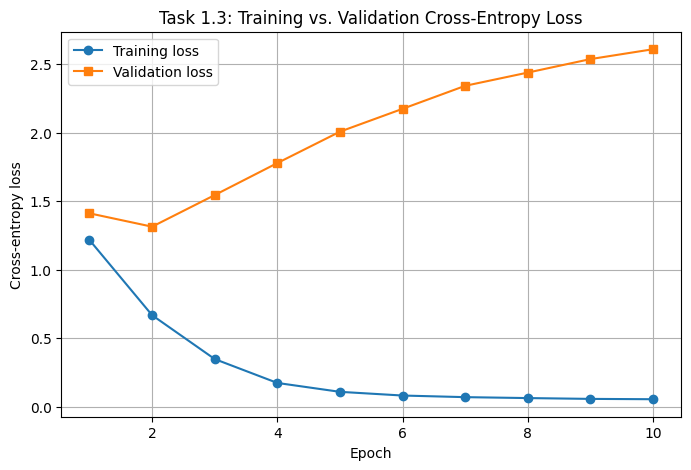

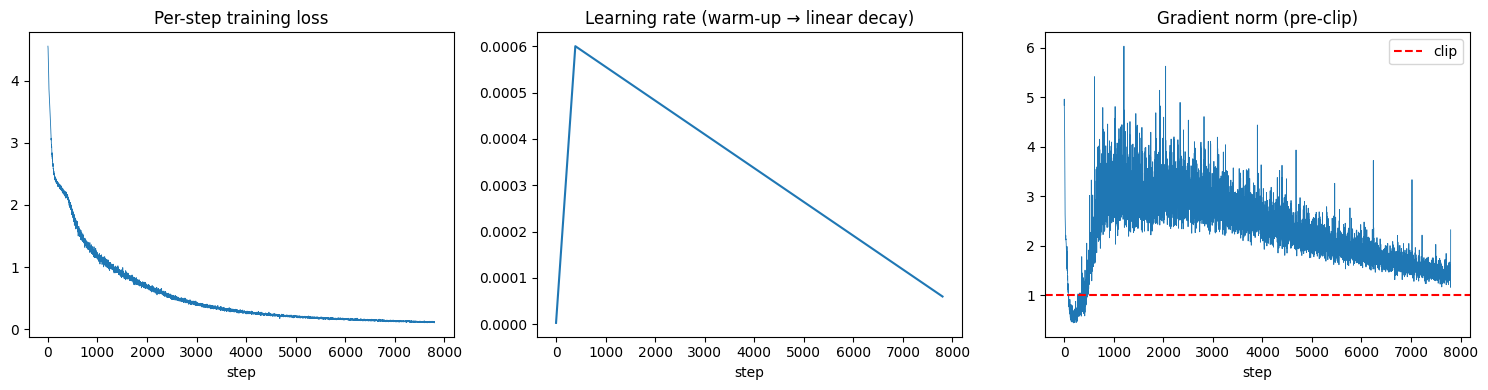

In [17]:
# 7. Curves: train/val loss per epoch, LR schedule, grad norm
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], marker='o', label='Training loss')
plt.plot(history["epoch"], history["val_loss"], marker='s', label='Validation loss')
plt.title('Task 1.3: Training vs. Validation Cross-Entropy Loss')
plt.xlabel('Epoch'); plt.ylabel('Cross-entropy loss'); plt.grid(True); plt.legend()
plt.savefig(f"{DIRS['outputs']}/loss_curves.png", dpi=150, bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(step_losses, lw=0.6); ax[0].set_title('Per-step training loss'); ax[0].set_xlabel('step')
ax[1].plot(lrs); ax[1].set_title('Learning rate (warm-up → linear decay)'); ax[1].set_xlabel('step')
ax[2].plot(grad_norms, lw=0.6); ax[2].axhline(CFG["grad_clip"], ls='--', c='r', label='clip')
ax[2].set_title('Gradient norm (pre-clip)'); ax[2].set_xlabel('step'); ax[2].legend()
plt.tight_layout(); plt.savefig(f"{DIRS['outputs']}/training_diagnostics.png", dpi=150, bbox_inches='tight'); plt.show()

In [18]:
# 8. Generation (greedy + temperature), speed, diversity samples saved for failure analysis
model.eval()
def gen(greedy, temp, seed):
    torch.manual_seed(seed)
    ctx = torch.tensor([[char_to_idx.get('\n', 0)]], device=device)
    if device == 'cuda': torch.cuda.synchronize()
    t0 = time.time()
    out = model.generate(ctx, CFG["gen_tokens"], temperature=temp, greedy=greedy)[0].tolist()
    if device == 'cuda': torch.cuda.synchronize()
    return decode(out[1:]), CFG["gen_tokens"] / (time.time() - t0)

samples = {"greedy": gen(True, 1.0, 0)}
for s in range(3):
    samples[f"temp{CFG['temperature']}_seed{s}"] = gen(False, CFG["temperature"], s)
generation_tokens_per_sec = sum(v[1] for v in samples.values()) / len(samples)

with open(f"{DIRS['outputs']}/generated_samples.txt", "w") as f:
    for name, (txt, _) in samples.items():
        f.write(f"===== {name} =====\n{txt}\n\n")
for name, (txt, _) in samples.items():
    log(f"SAMPLE {name}: {txt[:300]!r}")
log(f"generation speed {generation_tokens_per_sec:.1f} tokens/sec")

def distinct_n(tokens, n):
    ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
    return len(set(ngrams)) / len(ngrams) if ngrams else 0.0
def repeated_ngram_rate(tokens, n=4):
    ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
    return (len(ngrams) - len(set(ngrams))) / len(ngrams) if ngrams else 0.0

# diversity averaged over the temperature samples (greedy reported separately)
temp_txts = [v[0] for k, v in samples.items() if k != "greedy"]
avg = lambda f: sum(f(list(t)) for t in temp_txts) / len(temp_txts)
d1, d2, d3 = avg(lambda t: distinct_n(t, 1)), avg(lambda t: distinct_n(t, 2)), avg(lambda t: distinct_n(t, 3))
rep4 = avg(repeated_ngram_rate)
rep4_greedy = repeated_ngram_rate(list(samples["greedy"][0]))
log(f"Distinct-1/2/3 {d1:.4f}/{d2:.4f}/{d3:.4f} | repeated 4-gram {rep4*100:.2f}% (greedy {rep4_greedy*100:.2f}%)")

[2026-09-26T05:20:04] SAMPLE greedy: "Once upon a time, there was a little girl named Lily. She loved to eat blueberries. One day, Lily went to the park with her mom. There, she found a big blueberry bush with lots of sweet blueberries.\nLily was so happy to see the blueberries. But she was confused too. She didn't know if she could pick"
[2026-09-26T05:20:04] SAMPLE temp0.8_seed0: 'They saw a little hut. The hut had an open door. The cat said, "Let\'s go in!" The dog said, "I don\'t know. It\'s not our hut."\nThey went in anyway. Inside the hut, they saw a big tree. On the tree, there was a swing. The swing was hanging from a branch. The cat said, "I want to play on the swing!" Th'
[2026-09-26T05:20:04] SAMPLE temp0.8_seed1: '\nLily and Tom said bye-bye to the lady and went back to the park. They played some more, but they held their hats tight. They did not want to lose them again. They seemed happy and safe.\n<|endoftext|>\n\n\nSara and Tom were having lunch with their mom. They lik

In [19]:
# 9. Final metrics (full validation set) → metrics_report.csv + outputs/run_summary.json
import pandas as pd

final_val_loss, top1_acc = evaluate(X_val, Y_val)
final_train_loss, _ = evaluate(X_tr_eval, Y_tr_eval)
metrics = {
    "Training Cross-Entropy Loss": final_train_loss,
    "Validation Cross-Entropy Loss": final_val_loss,
    "Best Validation Loss": best_val,
    "Perplexity": math.exp(final_val_loss),
    "Bits-Per-Character (BPC)": final_val_loss / math.log(2),
    "Generalization Gap (Val - Train)": final_val_loss - final_train_loss,
    "Top-1 Next-Character Accuracy": top1_acc,
    "Distinct-1 (temp sampling)": d1,
    "Distinct-2 (temp sampling)": d2,
    "Distinct-3 (temp sampling)": d3,
    "Repeated 4-gram Rate (temp sampling)": rep4,
    "Repeated 4-gram Rate (greedy)": rep4_greedy,
    "Gradient Norm Mean": sum(grad_norms) / len(grad_norms),
    "Gradient Norm Max": max(grad_norms),
    "Gradient Norm Last": grad_norms[-1],
    "Loss Spikes": loss_spikes,
    "NaN/Inf Losses": nan_losses,
    "Parameter Count": param_count,
    "Training Throughput (tokens/sec)": train_tokens_per_sec,
    "Generation Speed (tokens/sec)": generation_tokens_per_sec,
    "Peak Memory Usage (MB)": peak_memory_mb,
    "Total Training Time (sec)": total_time,
    "Epochs": CFG["epochs"],
    "Optimizer Steps": step,
    "Device": torch.cuda.get_device_name(0) if device == 'cuda' else platform.processor() or "cpu",
}
df = pd.DataFrame({"Metric": list(metrics), "Value": list(metrics.values())})
df.to_csv(f"{OUT}/metrics_report.csv", index=False)
display(df)

run_summary = {k.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("/", "_per_"): v
               for k, v in metrics.items()}
run_summary["run_id"] = RUN_ID
run_summary["history"] = history
json.dump(run_summary, open(f"{DIRS['outputs']}/run_summary.json", "w"), indent=2)
log("METRICS " + json.dumps(metrics))

,Metric,Value
0,Training Cross-Entropy Loss,0.055398
1,Validation Cross-Entropy Loss,2.608655
2,Best Validation Loss,1.314026
3,Perplexity,13.580772
4,Bits-Per-Character (BPC),3.763494
5,Generalization Gap (Val - Train),2.553257
6,Top-1 Next-Character Accuracy,0.642027
7,Distinct-1 (temp sampling),0.076667
8,Distinct-2 (temp sampling),0.367401
9,Distinct-3 (temp sampling),0.629853


[2026-09-26T05:20:22] METRICS {"Training Cross-Entropy Loss": 0.0553982596939955, "Validation Cross-Entropy Loss": 2.6086549758911133, "Best Validation Loss": 1.3140264749526978, "Perplexity": 13.580772096016522, "Bits-Per-Character (BPC)": 3.7634935971084276, "Generalization Gap (Val - Train)": 2.553256716197118, "Top-1 Next-Character Accuracy": 0.6420272435897436, "Distinct-1 (temp sampling)": 0.07666666666666666, "Distinct-2 (temp sampling)": 0.36740146960587844, "Distinct-3 (temp sampling)": 0.6298527443105756, "Repeated 4-gram Rate (temp sampling)": 0.2293762575452716, "Repeated 4-gram Rate (greedy)": 0.2857142857142857, "Gradient Norm Mean": 2.3091898074478676, "Gradient Norm Max": 6.027122497558594, "Gradient Norm Last": 2.321993350982666, "Loss Spikes": 0, "NaN/Inf Losses": 0, "Parameter Count": 2750299, "Training Throughput (tokens/sec)": 95654.1843507542, "Generation Speed (tokens/sec)": 59.73162349732671, "Peak Memory Usage (MB)": 1273.18994140625, "Total Training Time (sec)

In [20]:
# 10. Manifest: environment, hardware, config, checkpoint → result mapping
manifest = {
    "run_id": RUN_ID,
    "member": CFG["member"],
    "task": "task1_llm",
    "timestamp": datetime.datetime.now().isoformat(timespec='seconds'),
    "python": sys.version, "torch": torch.__version__,
    "cuda": torch.version.cuda, "device": device,
    "gpu": torch.cuda.get_device_name(0) if device == 'cuda' else None,
    "cpu": sh("lscpu | grep 'Model name'") or platform.processor(),
    "config": CFG,
    "dataset_file": os.path.basename(file_path),
    "raw_log": LOG_PATH,
    "checkpoint_to_result": {
        f"{DIRS['checkpoints']}/final_model.pt": f"{OUT}/metrics_report.csv (all final metrics)",
        f"{DIRS['checkpoints']}/best_model.pt": f"best val loss {best_val:.4f}",
        **{f"{DIRS['checkpoints']}/epochs/epoch_{e:02d}.pt (Drive backup)": f"epoch {e} val loss {v:.4f}"
           for e, v in zip(history['epoch'], history['val_loss'])},
    },
    "pip_freeze": sh(f"{sys.executable} -m pip freeze").splitlines(),
}
MAN_PATH = f"{MAND}/task1_sadaf_{RUN_ID}.json"
json.dump(manifest, open(MAN_PATH, "w"), indent=2)
sh(f"{sys.executable} -m pip freeze > {MAND}/task1_sadaf_requirements_{RUN_ID}.txt")
log(f"manifest -> {MAN_PATH}")
log("files: " + json.dumps({d: sorted(os.listdir(p)) for d, p in DIRS.items()}))
_logf.flush()

[2026-09-26T05:20:31] manifest -> reproducibility/manifests/task1_sadaf_20260926_050656.json
[2026-09-26T05:20:31] files: {"src": [], "checkpoints": ["best_model.pt", "epochs", "final_model.pt"], "outputs": ["config.json", "generated_samples.txt", "loss_curves.png", "run_summary.json", "training_diagnostics.png"], "data_processed": ["split.pt"]}


In [22]:
# 11. Push to the team repo (skipped outside Colab)
REPO = "sadaffatimaee/DATA266_Lab1_Team16"
try:
    from google.colab import userdata
    token = userdata.get("GH_TOKEN")
except Exception:
    token = None

if not token:
    print("No GH_TOKEN (or not in Colab) — skipping push.")
else:
    import shutil
    base = os.getcwd()
    repo = "/content/repo"
    if os.path.exists(repo): shutil.rmtree(repo)
    subprocess.run(["git", "clone", "-q", f"https://{token}@github.com/{REPO}.git", repo], check=True)
    me = f"{repo}/{OUT}"
    os.makedirs(me, exist_ok=True)
    git = lambda *a: subprocess.run(["git", "-C", repo, *a], capture_output=True, text=True)

    # old layout → brief layout (keeps your existing write-ups, removes the fake run_summary)
    for old, new in [("task1_sadaf.ipynb", "src/task1_sadaf.ipynb"),
                     ("outputs/failure_analysis.md", "failure_analysis.md"),
                     ("outputs/results.md", "results.md")]:
        if os.path.exists(f"{me}/{old}") and not os.path.exists(f"{me}/{new}"):
            os.makedirs(os.path.dirname(f"{me}/{new}") or me, exist_ok=True)
            git("mv", f"{OUT}/{old}", f"{OUT}/{new}"); print("moved", old, "->", new)
    for stale in ["outputs/metrics_report.csv"]:
        if os.path.exists(f"{me}/{stale}"):
            git("rm", "-q", f"{OUT}/{stale}"); print("removed stale", stale)

    # copy this run's outputs (per-epoch checkpoints go to Drive, not GitHub, to keep the repo small)
    for sub in ["outputs", "data_processed"]:
        shutil.copytree(f"{base}/{DIRS[sub]}", f"{me}/{sub}", dirs_exist_ok=True)
    os.makedirs(f"{me}/checkpoints", exist_ok=True)
    for f in ["final_model.pt", "best_model.pt"]:
        shutil.copy(f"{base}/{DIRS['checkpoints']}/{f}", f"{me}/checkpoints/{f}")
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        dst = f"/content/drive/MyDrive/DATA266_Lab1_Checkpoints/Task1_Sadaf/{RUN_ID}"
        shutil.copytree(f"{base}/{DIRS['checkpoints']}", dst, dirs_exist_ok=True)
        shutil.copy(f"{base}/{LOG_PATH}", dst)
        print("All checkpoints backed up to Drive:", dst)
    except Exception as e:
        print("Drive backup skipped:", e)
    shutil.copy(f"{base}/{OUT}/metrics_report.csv", f"{me}/metrics_report.csv")
    for d in [LOGD, MAND]:
        shutil.copytree(f"{base}/{d}", f"{repo}/{d}", dirs_exist_ok=True)

    git("config", "user.name", "Sadaf Fatima Syeda")
    git("config", "user.email", "sadaffatima.syeda@sjsu.edu")
    git("add", "-A", OUT, LOGD, MAND)
    print(git("commit", "-m", f"Task 1 (Sadaf): run {RUN_ID} — checkpoints, metrics, curves, samples, log, manifest").stdout)
    r = git("push")
    print(r.stdout, r.stderr.replace(token, "***"))

Mounted at /content/drive
All checkpoints backed up to Drive: /content/drive/MyDrive/DATA266_Lab1_Checkpoints/Task1_Sadaf/20260926_050656
[main d273e4a] Task 1 (Sadaf): run 20260926_050656 — checkpoints, metrics, curves, samples, log, manifest
 14 files changed, 1781 insertions(+)
 create mode 100644 reproducibility/manifests/task1_sadaf_20260926_050656.json
 create mode 100644 reproducibility/manifests/task1_sadaf_requirements_20260926_050656.txt
 create mode 100644 reproducibility/raw_logs/task1_sadaf_20260926_050143.log
 create mode 100644 reproducibility/raw_logs/task1_sadaf_20260926_050259.log
 create mode 100644 reproducibility/raw_logs/task1_sadaf_20260926_050656.log
 create mode 100644 task1_llm/Sadaf_Fatima_Syeda/checkpoints/best_model.pt
 create mode 100644 task1_llm/Sadaf_Fatima_Syeda/checkpoints/final_model.pt
 create mode 100644 task1_llm/Sadaf_Fatima_Syeda/data_processed/split.pt
 create mode 100644 task1_llm/Sadaf_Fatima_Syeda/metrics_report.csv
 create mode 100644 task1

In [23]:

train_data = train_data.clone()
val_data = val_data.clone()
torch.save({"train_data": train_data, "val_data": val_data,
            "block_size": T, "stride": CFG["stride"],
            "chars": chars, "char_to_idx": char_to_idx, "idx_to_char": idx_to_char,
            "source_file": os.path.basename(file_path), "cfg": CFG},
           f"{DIRS['data_processed']}/split.pt")
print("split.pt size:", round(os.path.getsize(f"{DIRS['data_processed']}/split.pt") / 1e6, 2), "MB")

shutil.copy(f"{DIRS['data_processed']}/split.pt", f"/content/repo/{OUT}/data_processed/split.pt")
git("add", "-A", OUT)
print(git("commit", "--amend", "--no-edit").stdout[-300:])
r = git("push")
print(r.stdout, r.stderr.replace(token, "***"))

split.pt size: 0.88 MB
mode 100644 task1_llm/Sadaf_Fatima_Syeda/outputs/generated_samples.txt
 create mode 100644 task1_llm/Sadaf_Fatima_Syeda/outputs/loss_curves.png
 create mode 100644 task1_llm/Sadaf_Fatima_Syeda/outputs/run_summary.json
 create mode 100644 task1_llm/Sadaf_Fatima_Syeda/outputs/training_diagnostics.png

 To https://github.com/sadaffatimaee/DATA266_Lab1_Team16.git
   7c1394d..d135c26  main -> main

